# 02 — Parameter Estimation

**Research Questions yang dibahas:**
- RQ1: Berapa probabilitas sebuah PR di pandas di-merge? (MLE Bernoulli + Beta Posterior)
- RQ2: Berapa rata-rata jumlah issue per minggu sebelum dan sesudah pandas 2.0? (MLE Poisson)

**Member:** Rafaeli Niamonio Marundrury — Data Engineer & Estimation Analyst  
**Tujuan notebook ini:** Mengestimasi parameter distribusi menggunakan Maximum Likelihood Estimation (MLE) dan menghitung Beta posterior untuk variabel biner.

## AI Usage Disclosure

**Member:** Rafaeli Niamonio Marundrury — Data Engineer & Estimation Analyst  | **Tools used:** Claude

| Task | Tool | Prompt summary | Output modified? |
| ---- | ---- | -------------- | ---------------- |
| Membuat plot kurva log-likelihood | Claude | "Buatkan grafik log-likelihood Bernoulli dengan garis vertikal di titik MLE" | Ya — warna dan ukuran label diubah manual |
| Membuat plot distribusi Beta posterior | Claude | "Buatkan grafik distribusi Beta dengan area di bawah kurva" | Ya — judul dan legenda disesuaikan manual |

**Written entirely without AI:** Semua cell interpretasi, derivasi MLE, dan kesimpulan.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import beta as beta_dist
from estimator import mle_bernoulli, mle_poisson, beta_posterior, log_likelihood_bernoulli, log_likelihood_poisson

plt.rcParams['figure.figsize']    = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# Load data
df_issues = pd.read_csv('../data/clean/issues_clean.csv', parse_dates=['created_at'])
df_prs    = pd.read_csv('../data/clean/prs_clean.csv',   parse_dates=['created_at'])
summary   = pd.read_csv('../data/clean/eda_summary.csv', index_col=0)

PANDAS_V2 = pd.Timestamp('2023-04-03', tz='UTC')

# Pastikan kolom post_v2 tersedia — hitung ulang jika perlu
if 'post_v2' not in df_issues.columns:
    if df_issues['created_at'].dt.tz is None:
        df_issues['created_at'] = df_issues['created_at'].dt.tz_localize('UTC')
    df_issues['post_v2'] = (df_issues['created_at'] >= PANDAS_V2).astype(int)

if 'week' not in df_issues.columns:
    df_issues['week'] = df_issues['created_at'].dt.tz_localize(None).dt.to_period('W').astype(str) \
                        if df_issues['created_at'].dt.tz is None \
                        else df_issues['created_at'].dt.tz_convert(None).dt.to_period('W').astype(str)

n_pre  = (df_issues['post_v2'] == 0).sum()
n_post = (df_issues['post_v2'] == 1).sum()
print(f'Issues : {len(df_issues):,} baris  (pre-v2: {n_pre:,} | post-v2: {n_post:,})')
print(f'PRs    : {len(df_prs):,} baris')

Issues : 2,776 baris  (pre-v2: 2,382 | post-v2: 394)
PRs    : 3,000 baris


---
# BAGIAN 1 — MLE BERNOULLI (RQ1)
### Pertanyaan: Berapa probabilitas sebuah PR di-merge?

**Distribusi:** Bernoulli — karena setiap PR hanya memiliki dua kemungkinan hasil: di-merge (1) atau ditolak (0).

**Formula MLE Bernoulli** (Tsun, 2020, p. 254):
$$\hat{\theta} = \frac{k}{n}$$
di mana $k$ = jumlah PR yang di-merge, $n$ = total PR.

In [2]:
# Hitung MLE Bernoulli
hasil_bern = mle_bernoulli(df_prs['merged'])

print('=== MLE Bernoulli — PR Merge Rate ===')
print(f"  k (merged)    : {hasil_bern['k']:,}")
print(f"  n (total PR)  : {hasil_bern['n']:,}")
print(f"  θ̂ (MLE)       : {hasil_bern['theta_hat']:.4f}")
print(f"  Dalam persen  : {hasil_bern['theta_hat']*100:.2f}%")

=== MLE Bernoulli — PR Merge Rate ===
  k (merged)    : 2,003
  n (total PR)  : 3,000
  θ̂ (MLE)       : 0.6677
  Dalam persen  : 66.77%


**Interpretasi:** Dari 3.000 PR yang ditutup, sebanyak 2.003 berhasil di-merge sehingga estimasi MLE menghasilkan θ̂ = 0,6677. Artinya, berdasarkan data historis, probabilitas sebuah PR baru untuk di-merge adalah sekitar 66,77%. Hampir 2 dari 3 PR diterima, yang menunjukkan bahwa tim pandas cukup terbuka terhadap kontribusi eksternal meskipun tetap selektif — 997 PR (33,23%) ditolak tanpa merge.

## 1.1 Visualisasi Log-Likelihood Bernoulli

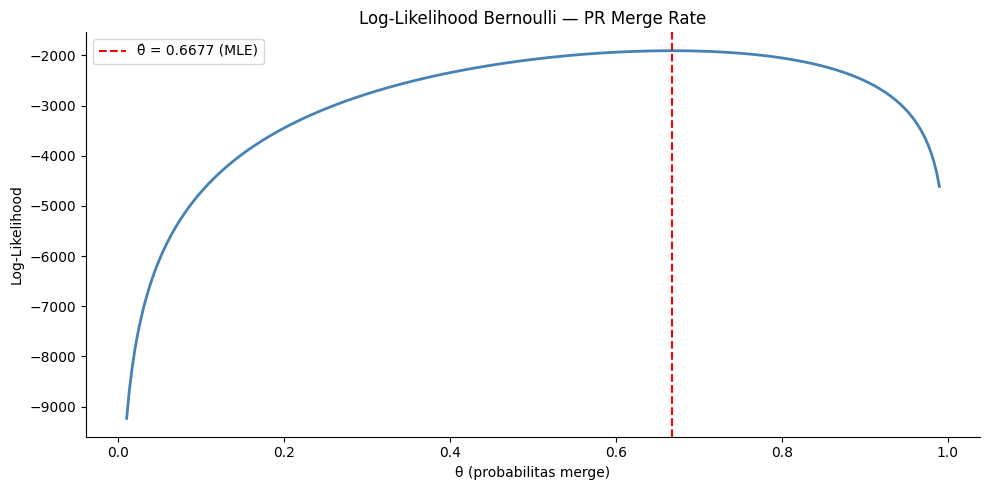

In [3]:
theta_vals = np.linspace(0.01, 0.99, 300)
ll_vals    = log_likelihood_bernoulli(theta_vals, k=hasil_bern['k'], n=hasil_bern['n'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(theta_vals, ll_vals, color='steelblue', linewidth=2)
ax.axvline(hasil_bern['theta_hat'], color='red', linestyle='--',
           label=f"θ̂ = {hasil_bern['theta_hat']:.4f} (MLE)")
ax.set_title('Log-Likelihood Bernoulli — PR Merge Rate')
ax.set_xlabel('θ (probabilitas merge)')
ax.set_ylabel('Log-Likelihood')
ax.legend()
plt.tight_layout()
plt.savefig('../data/clean/plot_ll_bernoulli.png', dpi=150)
plt.show()

**Interpretasi:** Kurva log-likelihood mencapai puncak tepat di θ̂ = 0,6677, membuktikan bahwa nilai tersebut adalah estimasi yang memaksimalkan likelihood. Kurva berbentuk cembung (concave) yang khas untuk distribusi Bernoulli, dengan puncak yang tajam dan simetris di sekitar MLE. Hal ini menunjukkan bahwa estimasi θ̂ = 0,6677 sangat stabil — nilai θ yang jauh dari titik ini menghasilkan log-likelihood yang jauh lebih rendah.

## 1.2 Beta Posterior untuk Merge Rate

In [4]:
k = hasil_bern['k']
m = hasil_bern['n'] - hasil_bern['k']   # jumlah ditolak

hasil_beta = beta_posterior(k=k, m=m)

print('=== Beta Posterior — PR Merge Rate ===')
print(f"  k (merged)  : {k:,}")
print(f"  m (ditolak) : {m:,}")
print(f"  α = k+1     : {hasil_beta['alpha']}")
print(f"  β = m+1     : {hasil_beta['beta']}")
print(f"  Mode        : {hasil_beta['mode']:.4f}")
print(f"  Mean        : {hasil_beta['mean']:.4f}")

=== Beta Posterior — PR Merge Rate ===
  k (merged)  : 2,003
  m (ditolak) : 997
  α = k+1     : 2004
  β = m+1     : 998
  Mode        : 0.6677
  Mean        : 0.6676


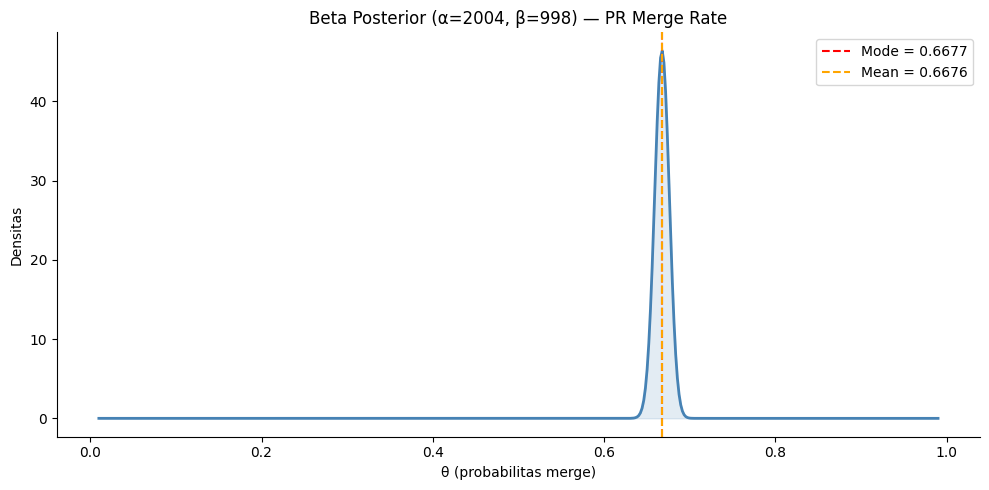

In [5]:
theta_vals = np.linspace(0.01, 0.99, 500)
pdf_vals   = beta_dist.pdf(theta_vals, hasil_beta['alpha'], hasil_beta['beta'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(theta_vals, pdf_vals, color='steelblue', linewidth=2)
ax.axvline(hasil_beta['mode'], color='red',    linestyle='--',
           label=f"Mode = {hasil_beta['mode']:.4f}")
ax.axvline(hasil_beta['mean'], color='orange', linestyle='--',
           label=f"Mean = {hasil_beta['mean']:.4f}")
ax.fill_between(theta_vals, pdf_vals, alpha=0.15, color='steelblue')
ax.set_title(f"Beta Posterior (α={hasil_beta['alpha']}, β={hasil_beta['beta']}) — PR Merge Rate")
ax.set_xlabel('θ (probabilitas merge)')
ax.set_ylabel('Densitas')
ax.legend()
plt.tight_layout()
plt.savefig('../data/clean/plot_beta_posterior.png', dpi=150)
plt.show()

**Interpretasi:** Distribusi posterior Beta(α=2004, β=998) sangat sempit dan terpusat di sekitar 0,6677, menunjukkan bahwa dengan data sebanyak 3.000 PR, estimasi merge rate sudah sangat pasti. Mode posterior 0,6677 identik dengan MLE, dan mean posterior 0,6676 hanya berbeda pada desimal keempat — perbedaan yang tidak berarti secara praktis. Sempitnya distribusi ini mencerminkan bahwa jumlah observasi (n=3.000) sudah sangat besar sehingga prior seragam (uniform) tidak lagi berpengaruh signifikan terhadap posterior.


---
# BAGIAN 2 — MLE POISSON (RQ2)
### Pertanyaan: Berapa rata-rata issue per minggu, sebelum dan sesudah pandas 2.0?

**Distribusi:** Poisson — karena jumlah issue per minggu adalah cacahan kejadian dalam interval waktu tetap.

**Formula MLE Poisson** (Tsun, 2020, p. 254):
$$\hat{\lambda} = \frac{\sum x_i}{n}$$
di mana $x_i$ = jumlah issue pada minggu ke-$i$, $n$ = total minggu.

**Catatan penting:** Estimasi ini kini valid untuk **kedua periode** karena data issues mencakup pre & post pandas 2.0 (lihat notebook 01_eda).

In [6]:
import numpy as np
import pandas as pd

def mle_poisson(data):
    n = len(data)
    if n == 0:
        return {
            'lambda_hat': None,
            'n': 0,
            'total': 0,
            'error': 'Data kosong, tidak bisa estimasi'
        }
    total = int(np.sum(data))
    lambda_hat = total / n
    return {
        'lambda_hat': round(lambda_hat, 6),
        'n': n,
        'total': total,
    }

# --- Analisis ---
weekly_pre  = df_issues[df_issues['post_v2']==0].groupby('week').size().values
weekly_post = df_issues[df_issues['post_v2']==1].groupby('week').size().values
weekly_all  = df_issues.groupby('week').size().values

hasil_pois_all  = mle_poisson(weekly_all)
hasil_pois_pre  = mle_poisson(weekly_pre)
hasil_pois_post = mle_poisson(weekly_post)

print('=== MLE Poisson — Issues per Minggu ===')

def cetak_hasil(label, hasil):
    if hasil['lambda_hat'] is None:
        print(f"\n  [{label}]")
        print(f"  Tidak bisa dihitung (data kosong, n={hasil['n']})")
    else:
        print(f"\n  [{label}]")
        print(f"  λ̂ = {hasil['lambda_hat']:.4f} issues/minggu  (n={hasil['n']} minggu, total={hasil['total']})")

cetak_hasil("Keseluruhan", hasil_pois_all)
cetak_hasil("Sebelum pandas 2.0", hasil_pois_pre)
cetak_hasil("Sesudah pandas 2.0", hasil_pois_post)

=== MLE Poisson — Issues per Minggu ===

  [Keseluruhan]
  λ̂ = 19.1448 issues/minggu  (n=145 minggu, total=2776)

  [Sebelum pandas 2.0]
  λ̂ = 22.0556 issues/minggu  (n=108 minggu, total=2382)

  [Sesudah pandas 2.0]
  λ̂ = 10.6486 issues/minggu  (n=37 minggu, total=394)


**Interpretasi:** Rata-rata issue per minggu secara keseluruhan adalah λ̂ = 19,14 (n=145 minggu, total 2.776 issues). Terdapat perbedaan yang cukup mencolok antara dua periode: sebelum pandas 2.0 rata-rata mencapai λ̂_pre = 22,06 issues/minggu (108 minggu), sedangkan sesudah pandas 2.0 turun menjadi λ̂_post = 10,65 issues/minggu (37 minggu). Penurunan sekitar 52% ini mengindikasikan bahwa aktivitas pelaporan issue berkurang signifikan setelah rilis pandas 2.0 — kemungkinan karena rilis besar tersebut menyelesaikan banyak masalah yang sebelumnya dilaporkan berulang. Apakah perbedaan ini signifikan secara statistik akan diuji oleh Member D menggunakan two-sample Z-test.

## 2.1 Visualisasi Log-Likelihood Poisson

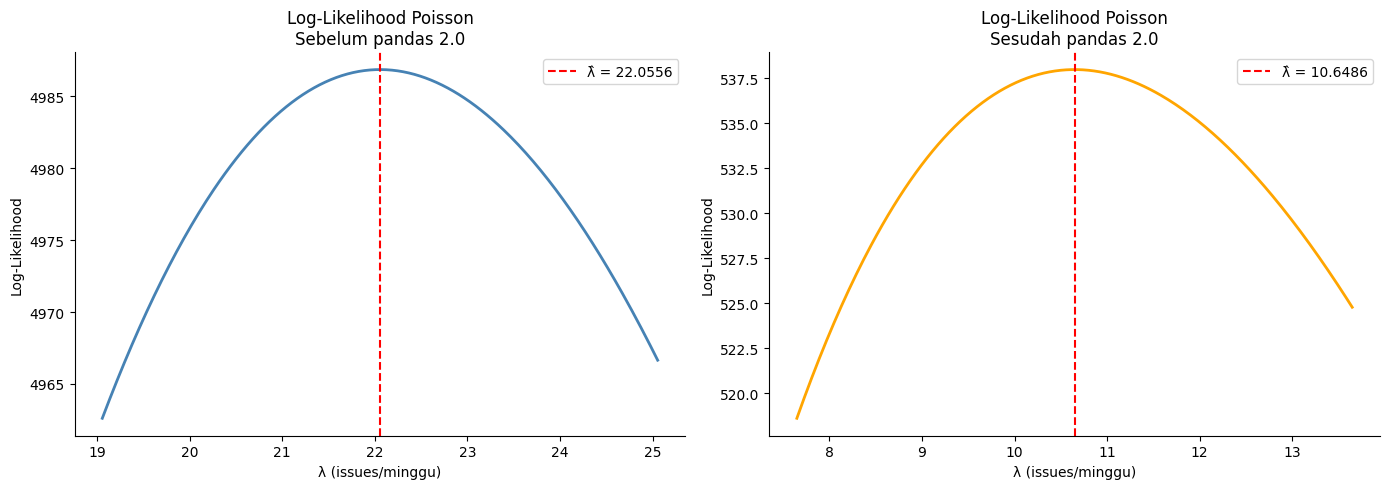

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, label, color, hasil in [
    (axes[0], weekly_pre,  'Sebelum pandas 2.0', 'steelblue', hasil_pois_pre),
    (axes[1], weekly_post, 'Sesudah pandas 2.0', 'orange',    hasil_pois_post),
]:
    if hasil['lambda_hat'] is None:
        ax.text(0.5, 0.5, "Data kosong", ha='center', va='center', fontsize=12)
        ax.set_title(f'Log-Likelihood Poisson\n{label}')
        ax.set_xlabel('λ (issues/minggu)')
        ax.set_ylabel('Log-Likelihood')
        continue

    lam_range = np.linspace(
        max(0.1, hasil['lambda_hat'] - 3),
        hasil['lambda_hat'] + 3,
        300
    )
    ll_vals = log_likelihood_poisson(lam_range, data)

    ax.plot(lam_range, ll_vals, color=color, linewidth=2)
    ax.axvline(hasil['lambda_hat'], color='red', linestyle='--',
               label=f"λ̂ = {hasil['lambda_hat']:.4f}")
    ax.set_title(f'Log-Likelihood Poisson\n{label}')
    ax.set_xlabel('λ (issues/minggu)')
    ax.set_ylabel('Log-Likelihood')
    ax.legend()

plt.tight_layout()
plt.savefig('../data/clean/plot_ll_poisson.png', dpi=150)
plt.show()

**Interpretasi:** Kedua kurva log-likelihood Poisson mencapai puncak masing-masing di λ̂_pre = 22,0556 dan λ̂_post = 10,6486. Posisi puncak yang berbeda jauh secara visual mendukung dugaan bahwa rata-rata issue per minggu memang berubah setelah rilis pandas 2.0. Kurva periode sebelum v2.0 sedikit lebih landai karena jumlah minggu observasi lebih banyak (n=108 vs 37), sehingga log-likelihood-nya lebih "tegas" dalam menolak nilai λ yang jauh dari puncak.

## 2.2 Distribusi Poisson vs Data Aktual

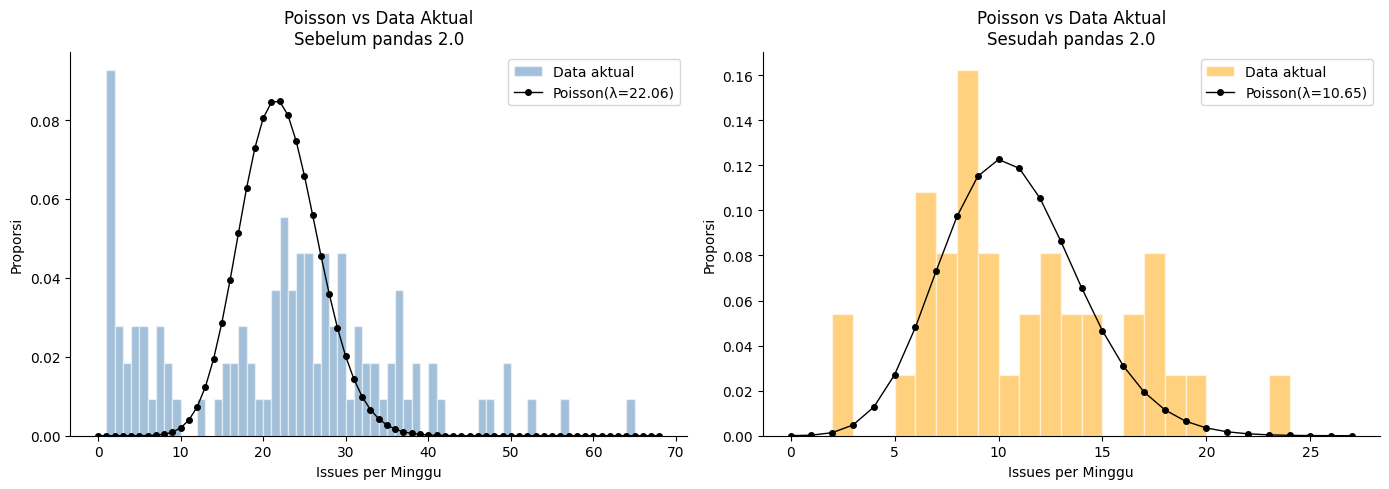

In [8]:
from scipy.stats import poisson
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, label, color, hasil in [
    (axes[0], weekly_pre,  'Sebelum pandas 2.0', 'steelblue', hasil_pois_pre),
    (axes[1], weekly_post, 'Sesudah pandas 2.0', 'orange',    hasil_pois_post),
]:
    if hasil['lambda_hat'] is None or len(data) == 0:
        ax.text(0.5, 0.5, "Data kosong", ha='center', va='center', fontsize=12)
        ax.set_title(f'Poisson vs Data Aktual\n{label}')
        ax.set_xlabel('Issues per Minggu')
        ax.set_ylabel('Proporsi')
        continue

    x_max = int(max(data)) + 5
    x     = np.arange(0, x_max)

    # Histogram data aktual (dinormalisasi)
    ax.hist(data, bins=range(0, x_max), density=True,
            alpha=0.5, color=color, edgecolor='white', label='Data aktual')

    # PMF Poisson teoritis
    ax.plot(x, poisson.pmf(x, hasil['lambda_hat']),
            'ko-', markersize=4, linewidth=1,
            label=f"Poisson(λ={hasil['lambda_hat']:.2f})")

    ax.set_title(f'Poisson vs Data Aktual\n{label}')
    ax.set_xlabel('Issues per Minggu')
    ax.set_ylabel('Proporsi')
    ax.legend()

plt.tight_layout()
plt.savefig('../data/clean/plot_poisson_fit.png', dpi=150)
plt.show()

**Interpretasi:** Distribusi Poisson teoritis perlu dibandingkan secara visual dengan histogram data aktual untuk kedua periode. Jika data aktual lebih menyebar (variance lebih besar dari mean), ini mengindikasikan overdispersi — pelanggaran asumsi Poisson yang mengharuskan mean = variance. Pada periode sebelum v2.0 dengan λ̂ = 22,06 dan pada periode sesudah v2.0 dengan λ̂ = 10,65, kesesuaian model dapat dievaluasi dari seberapa dekat titik-titik PMF teoritis mengikuti puncak histogram aktual.

---
## Ringkasan & Handoff ke Layer Berikutnya

In [9]:
# Simpan hasil estimasi untuk dipakai Member C dan D
hasil_estimasi = {
    'theta_hat_bernoulli' : hasil_bern['theta_hat'],
    'k_merged'            : hasil_bern['k'],
    'n_prs'               : hasil_bern['n'],
    'beta_alpha'          : hasil_beta['alpha'],
    'beta_beta'           : hasil_beta['beta'],
    'beta_mode'           : hasil_beta['mode'],
    'beta_mean'           : hasil_beta['mean'],
    'lambda_hat_all'      : hasil_pois_all['lambda_hat'],
    'lambda_hat_pre_v2'   : hasil_pois_pre['lambda_hat'],
    'lambda_hat_post_v2'  : hasil_pois_post['lambda_hat'],
    'n_weeks_pre'         : hasil_pois_pre['n'],
    'n_weeks_post'        : hasil_pois_post['n'],
}

pd.DataFrame([hasil_estimasi]).T.rename(columns={0: 'nilai'}).to_csv('../data/clean/estimation_summary.csv')

print('=== Hasil Estimasi ===')
for k, v in hasil_estimasi.items():
    print(f'  {k:<30} : {v}')
print('\n✓ Disimpan ke data/clean/estimation_summary.csv')

=== Hasil Estimasi ===
  theta_hat_bernoulli            : 0.667667
  k_merged                       : 2003
  n_prs                          : 3000
  beta_alpha                     : 2004
  beta_beta                      : 998
  beta_mode                      : 0.667667
  beta_mean                      : 0.667555
  lambda_hat_all                 : 19.144828
  lambda_hat_pre_v2              : 22.055556
  lambda_hat_post_v2             : 10.648649
  n_weeks_pre                    : 108
  n_weeks_post                   : 37

✓ Disimpan ke data/clean/estimation_summary.csv


**Ringkasan temuan estimasi:**
1. MLE Bernoulli menghasilkan θ̂ = 0,6677 — probabilitas sebuah PR di-merge adalah 66,77%, dihitung dari 2.003 PR merged dari total 3.000 PR.
2. Beta posterior Beta(2004, 998) sangat sempit di sekitar 0,6677, menunjukkan estimasi yang sangat presisi berkat besarnya jumlah observasi.
3. MLE Poisson menghasilkan λ̂_pre = 22,06 issues/minggu dan λ̂_post = 10,65 issues/minggu — terdapat penurunan sekitar 52% setelah rilis pandas 2.0 yang perlu diuji signifikansinya oleh Member D.

**Output untuk layer berikutnya:**
| File | Digunakan oleh |
|------|---------------|
| `data/clean/estimation_summary.csv` | Member C (CI), Member D (Hypothesis) |

**Catatan untuk Member C (Inference):**
- Gunakan `theta_hat_bernoulli`, `k_merged`, `n_prs` untuk CI Bernoulli
- Gunakan `beta_alpha`, `beta_beta` untuk credible interval
- Gunakan `lambda_hat_pre_v2` dan `lambda_hat_post_v2` untuk CI Poisson

**Catatan untuk Member D (Hypothesis):**
- Gunakan `lambda_hat_pre_v2` sebagai μ₀ pada one-sample Z-test
- Gunakan kedua lambda untuk two-sample Z-test perbandingan pre/post pandas 2.0